## Day 1 – Data Understanding & Problem Framing

## Manufacturing Defect Analysis
Data Understanding

In [3]:
import pandas as pd
import os
# Create Project Structure
project_name = "defect_analysis"

folders = [
    f"{project_name}/data",
    f"{project_name}/notebooks",
    f"{project_name}/reports",
    f"{project_name}/src"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created!")
print("Checking Project Structure:\n")

for root, dirs, files in os.walk(project_name):
    level = root.replace(project_name, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    
    subindent = " " * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")


Project folders created!
Checking Project Structure:

defect_analysis/
    data/
    notebooks/
    reports/
    src/


## Task 1
Load dataset

In [4]:
df = pd.read_csv("C:/Users/Priti/Downloads/defects_data.csv")
df
print("\n Dataset Loaded Successfully!")

# Shape (rows, columns)
print("\nShape of Dataset:")
print(df.shape)

# Column Names
print("\nColumn Names:")
print(df.columns)

# Data Types
print("\nData Types:")
print(df.dtypes)

# Missing Values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

#  Unique Categories

print("Unique Values in Each Column:")
for col in df.columns:
    print(f"\nColumn: {col}")
    print("Number of Unique Values:", df[col].nunique())
    print("Unique Values:", df[col].unique())
    

# First 5 Rows
print("\nFirst 5 Records:")
print(df.head())

# Basic Statistics (Numerical Columns)
print("\nStatistical Summary:")
print(df.describe())

# Duplicate Entri
print(" Duplicate Rows:")
(df.duplicated().sum())


 Dataset Loaded Successfully!

Shape of Dataset:
(1000, 8)

Column Names:
Index(['defect_id', 'product_id', 'defect_type', 'defect_date',
       'defect_location', 'severity', 'inspection_method', 'repair_cost'],
      dtype='object')

Data Types:
defect_id              int64
product_id             int64
defect_type           object
defect_date           object
defect_location       object
severity              object
inspection_method     object
repair_cost          float64
dtype: object

Missing Values in Each Column:
defect_id            0
product_id           0
defect_type          0
defect_date          0
defect_location      0
severity             0
inspection_method    0
repair_cost          0
dtype: int64
Unique Values in Each Column:

Column: defect_id
Number of Unique Values: 1000
Unique Values: [   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36

np.int64(0)

##  Identify: 
• Target variable (e.g., defect count / defect type / severity)

In [5]:
# Example: Checking possible target columns
print("\nUnique values in each column:\n")

for col in df.columns:
    print(f"{col} → {df[col].nunique()} unique values")


Unique values in each column:

defect_id → 1000 unique values
product_id → 100 unique values
defect_type → 3 unique values
defect_date → 182 unique values
defect_location → 3 unique values
severity → 3 unique values
inspection_method → 3 unique values
repair_cost → 996 unique values


In [6]:
# Operational Variables
operational_columns = []

for col in df.columns:
    if any(word in col.lower() for word in ["shift", "machine", "operator", "line"]):
        operational_columns.append(col)

print("\nOperational Variables:")
print(operational_columns)


Operational Variables:
[]


## 
that means your dataset does not contain those words in column names.

In [7]:
print(df.columns)
# Operational Variables
operational_columns = []

for col in df.columns:
    if any(word in col.lower() for word in ["severity", "defect_type"]):
        operational_columns.append(col)

print("\nOperational Variables:")
print(operational_columns)

Index(['defect_id', 'product_id', 'defect_type', 'defect_date',
       'defect_location', 'severity', 'inspection_method', 'repair_cost'],
      dtype='object')

Operational Variables:
['defect_type', 'severity']


## Task 4
 Define 5 business questions, such as: 


Most Frequent Defect Type:
defect_type
Structural    352
Functional    339
Cosmetic      309
Name: count, dtype: int64


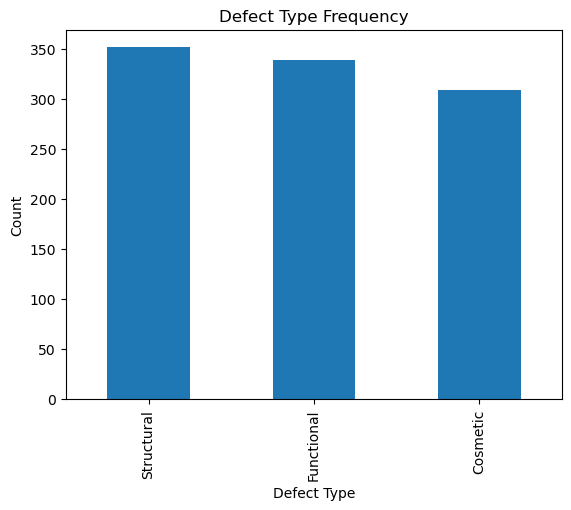

In [8]:
# Which defect type is most frequent? 
print("\nMost Frequent Defect Type:")
print(df['defect_type'].value_counts())

# Visualization
import matplotlib.pyplot as plt
df['defect_type'].value_counts().plot(kind='bar')
plt.title("Defect Type Frequency")
plt.xlabel("Defect Type")
plt.ylabel("Count")
plt.show()

In [9]:
df['defect_date'].head()

0    06-06-2024
1     4/26/2024
2     2/15/2024
3     3/28/2024
4     4/26/2024
Name: defect_date, dtype: object

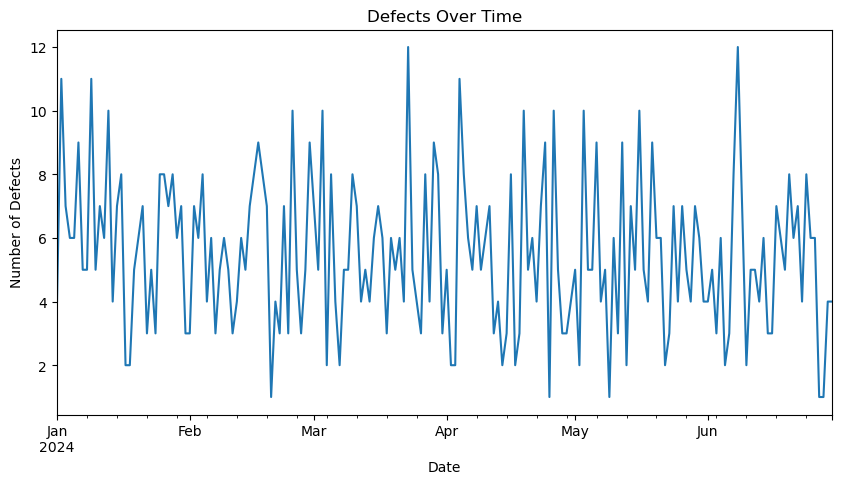

In [19]:
 #  Are defects increasing over time?
df['defect_date'] = pd.to_datetime(df['defect_date'], format='mixed')
defects_by_date = df.groupby('defect_date').size()

defects_by_date.plot(figsize=(10,5))

plt.title("Defects Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Defects")
plt.show()

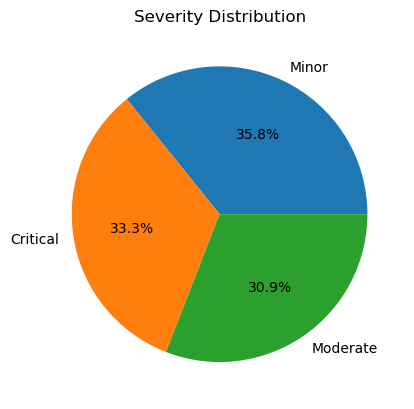

In [16]:
# Which severity produces more defects? 
df['severity'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Severity Distribution")
plt.ylabel("")
plt.show()

In [17]:
print("Columns in your dataset:\n")
print(df.columns)

Columns in your dataset:

Index(['defect_id', 'product_id', 'defect_type', 'defect_date',
       'defect_location', 'severity', 'inspection_method', 'repair_cost'],
      dtype='object')
